# Ucitavanje potrebnih biblioteka

In [94]:
USE_WIDGETS = True

def importEssentialLibs(USE_WIDGETS):
    import numpy as np
    if USE_WIDGETS:
        %matplotlib widget
    else:
        %matplotlib inline
    import matplotlib as mpl
    mpl.rc('text', usetex = True)
    mpl.rc('font', family = 'serif', size = 18)
    import matplotlib.pyplot as plt
    
    return np, mpl, plt

np, mpl, plt = importEssentialLibs(USE_WIDGETS)
from IPython.display import Markdown, display
# mpl.rc('text', usetex = True)
import scipy.fft as fft
import IPython
from IPython.display import Markdown
from scipy.io import wavfile
from scipy.signal import chirp, spectrogram
import scipy.signal as signal
import pickle 
import scipy.io as sio
from scipy.signal import butter, lfilter, freqz
from scipy.signal import firwin, convolve
from fxpmath import Fxp
from signal_utils import *

In [95]:
def saturate_q1n(value, n_frac):
    """Clamp integer to signed Q1.n_frac range"""
    min_val = -(1 << (n_frac))
    max_val = (1 << (n_frac)) - 1
    return max(min(value, max_val), min_val)

def saturate_qmn(value: int, m_int: int, n_frac: int) -> int:
    """
    Saturate signed fixed-point integer in Qm.n format.

    Args:
        value   : int - raw integer value
        m_int   : int - number of integer bits (includes sign bit)
        n_frac  : int - number of fractional bits

    Returns:
        Saturated integer that fits in Qm.n range
    """
    total_bits = m_int + n_frac
    min_val = -(1 << (m_int - 1)) * (1 << n_frac)         # -2^(m-1) * 2^n = raw int min
    max_val = ((1 << (m_int - 1))) * (1 << n_frac) - 1 # (2^(m-1) - 2^-n) as int
    # print(min_val, max_val)

    return max(min(value, max_val), min_val)

def normalize_to_q1n(signal, n_frac):
    """Convert float list to Q1.n_frac fixed-point signed integers"""
    max_val = np.max(np.abs(signal))
    if max_val == 0:
        return [0] * len(signal)

    scale = (1 << n_frac) - 1  # 32767 for Q1.15
    return [int(round(x / max_val * scale)) for x in signal]

def float_to_q1n(signal, n_frac):
    # signal /= np.max(n_frac)
    """Convert float list to Q1.n_frac fixed-point signed integers"""
    scale = 1 << n_frac  # 2^n_frac
    max_val = (1 << (n_frac)) - 1  # maximum positive integer value
    min_val = -1 << n_frac         # minimum negative value

    result = []
    for x in signal:
        val = int(round(x * scale))
        val = min(max(val, min_val), max_val)  # saturate to range
        result.append(val)
    return result

def fir_direct_q1n(x_q, h_q, n_frac, saturate=True):
    """
    Fixed-point Direct FIR filter in Q1.n_frac format (1 integer bit + n_frac fractional).
    
    Parameters:
        x       : input samples (float or int)
        h       : coefficients (float or int)
        n_frac  : number of fractional bits
    Returns:
        y_q1n   : output list of Q1.n_frac integers (saturated)
    """
    N = len(h_q)

    y_q = np.zeros(len(x_q))
    for n in range(len(x_q)):
        acc = 0  # Accumulator in Q2.(2*n_frac)
        for i in range(N):
            if n - i >= 0:
                product = h_q[i] * x_q[n - i]  # Q1.n × Q1.n = Q2.2n
                acc = saturate_qmn(acc+product, m_int=2, n_frac=2*n_frac)
                # acc += product

        # Shift from Q2.2n → Q1.n
        if saturate:
            acc >>= n_frac+1

        # Saturate back to Q1.n range
        # y = saturate_q1n(acc, n_frac)
        y_q[n] = acc

    return y_q

def fir_transposed_q1n(x_q, h_q, n_frac, saturate=True):
    """
    Fixed-point Transposed FIR filter in Q1.n_frac format (1 integer bit + n_frac fractional).
    
    Parameters:
        x       : input samples (float or int)
        h       : coefficients (float or int)
        n_frac  : number of fractional bits
    Returns:
        y_q1n   : output list of Q1.n_frac integers (saturated)
    """
    N = len(h_q)
    # delay_line[i] will hold s_{i+1}[n-1], for i=0..N-2
    delay_line = np.zeros(N-1, dtype="int")
    y_q = np.zeros(len(x_q), dtype="int")

    for n in range(len(x_q)):
        # 1) accumulate tap-0 + the oldest partial sum (delay_line[0])
        acc = saturate_qmn(h_q[0] * x_q[n] + delay_line[0], m_int=2, n_frac=2*n_frac)

        # 2) shift through the rest of the delay line:
        #    new s1 = h[1]*xn + old s2
        #    new s2 = h[2]*xn + old s3
        #    … 
        for i in range(N - 2):
            delay_line[i] = saturate_qmn(h_q[i+1] * x_q[n] + delay_line[i+1], m_int=2, n_frac=2*n_frac)

        # 3) last stage has no following partial sum:
        delay_line[N-2] = h_q[N-1] * x_q[n]

        # 4) bring back from Q2.2n to Q1.n_frac
        if saturate:
            acc >>= n_frac+1

        # 5) saturate into Q1.n_frac range
        y_q[n] = acc #saturate_q1n(acc, n_frac)

    return y_q

def poly_decimation_q1n(x_q, h_q, D, n_frac):
    x_q = np.asarray(x_q)
    pad = (-len(x_q)) % D
    if pad > 0:
        x_q = np.concatenate([x_q, np.zeros(pad, dtype=x_q.dtype)])
        
    poly_h_q = makePolyphase(h_q, D)  # shape: (D, n)

    Nout = int(np.ceil(len(x_q) / D))
    acc = np.zeros(Nout, dtype=x_q.dtype)

    n = poly_h_q.shape[1]  # taps per phase

    for i in range(D):
        # grab every D-th sample starting at offset i
        FIR_in = x_q[i::D]
        # FIR_in = x_q[i::D]
        # filter with the reversed polyphase order
        tmp = fir_transposed_q1n(FIR_in, poly_h_q[D-1-i], n_frac=2*n_frac, saturate=False)

        # clip tmp to avoid overshooting acc length
        # acc = saturate_qmn(acc + tmp, m_int = 2, n_frac=2*n_frac)
        for k in range(len(acc)):
            acc[k] = saturate_qmn(acc[k] + tmp[k], m_int=2, n_frac=2*n_frac)

    # shift & saturate
    for k in range(Nout):
        v = acc[k] >> n_frac+1
        acc[k] = v

    return acc


## Test signal

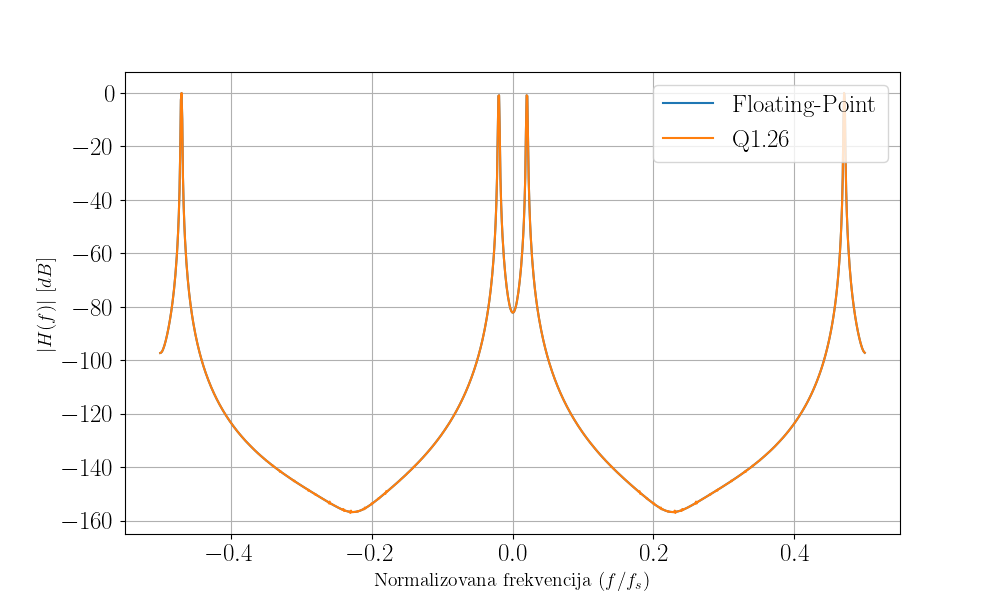

In [96]:
N = 1024
n = np.arange(N)
F1 = 0.02
F2 = 0.47
n_frac = 26

xin_fir = 1.0*np.sin(2*np.pi*F1*n) + 1.0*np.sin(2*np.pi*F2*n)
xin_fir_q = np.array(float_to_q1n(xin_fir/np.max(xin_fir), n_frac))

xin_fftdB = fftdB(xin_fir, win=True)
xin_fftdB -= np.max(xin_fftdB)
xin_q_fftdB = fftdB(xin_fir_q, win=True)
xin_q_fftdB -= np.max(xin_q_fftdB)
freqs = np.linspace(-0.5, 0.5, N)

plt.figure(figsize=(10, 6))
plt.plot(freqs, xin_fftdB, label = "Floating-Point")
plt.plot(freqs, xin_q_fftdB, label = f"Q1.{n_frac}")
plt.grid()
plt.legend()
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.show();

## FIR Generation

$A_{dB} = 40$

$F_{max} = 0.425$

$F_{\text{pass}} = 0.1300, \quad F_{\text{stop}} = 0.2300$

$N = 21$

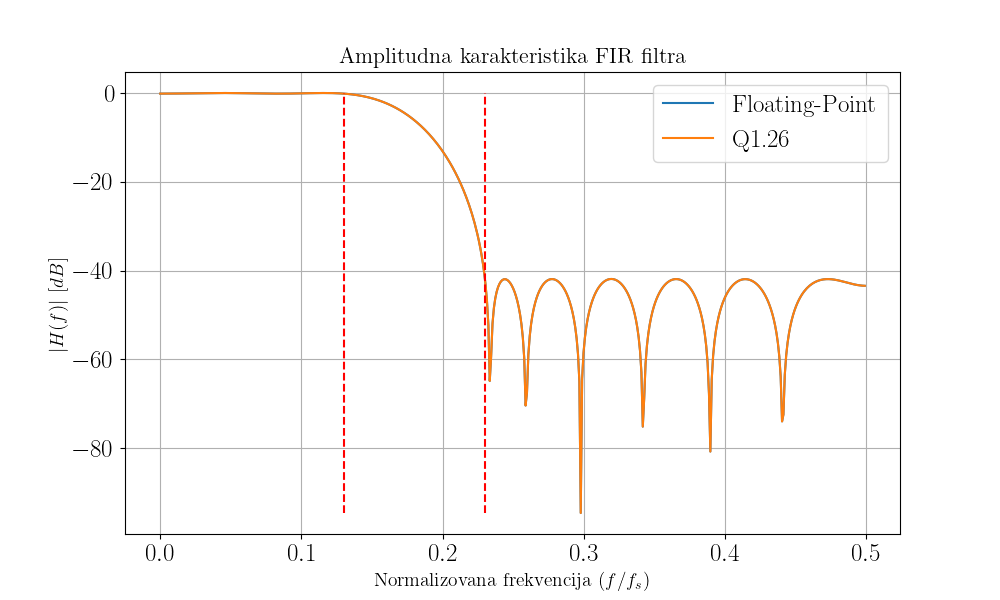

In [100]:
D = 2
AdB = 40
display(Markdown((rf"$A_{{dB}} = {AdB}$")))
deltaPass = 10**(-AdB/20)
deltaStop = deltaPass

perc = 0.15
Fmax = 0.5 * (1 - perc)
display(Markdown((rf"$F_{{max}} = {Fmax}$")))
# Fpass = Fmax / D
# Fstop = 0.5 / D
Fstop = 0.23
Fpass = Fstop - 0.1

display(Markdown(rf"$F_{{\text{{pass}}}} = {Fpass:.4f}, \quad F_{{\text{{stop}}}} = {Fstop:.4f}$"))

fir_coeff = remezlp(Fpass, Fstop, deltaPass, deltaStop, even_n=False, nPoints=N, Nmax=N)
fir_coeff_q = np.array(float_to_q1n(fir_coeff, n_frac))

display(Markdown((rf"$N = {len(fir_coeff)}$")))

w, h = scipy.signal.freqz(fir_coeff)
H = 20*np.log10(abs(h))
H -= np.max(H)
w_q, h_q = scipy.signal.freqz(fir_coeff_q)
H_q = 20*np.log10(abs(h_q))
H_q -= np.max(H_q)

plt.figure(figsize=(10, 6))
plt.plot(w/(2*np.pi), H, label=r'Floating-Point');
plt.plot(w_q/(2*np.pi), H_q, label=rf'Q1.{n_frac}');
plt.legend()
plt.plot([Fpass,Fpass], [np.min(H), 0], 'r--');
plt.plot([Fstop,Fstop], [np.min(H), 0], 'r--');
plt.title(r'Amplitudna karakteristika FIR filtra', fontsize=16)
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.grid(True)
plt.show();

## Testing FIR Inplementation

### Signal Generation

In [101]:
np.savetxt("../vhdl/data/fir/fir_coeffs.txt", fir_coeff_q, fmt="%d")
np.savetxt("../vhdl/data/fir/input/xin.txt", xin_fir_q, fmt="%d")

# poly_fir_coeff_q = makePolyphase(fir_coeff_q, 2)
# poly0, poly1 = poly_fir_coeff_q[0], poly_fir_coeff_q[1]

# np.savetxt("../vhdl/data/fir/poly0.txt", poly0, fmt="%d")
# np.savetxt("../vhdl/data/fir/poly1.txt", poly1, fmt="%d")

### Python and VHDL Comparison

Direct error sum: 11348899970.0
Transposed error sum: 11348899970.0


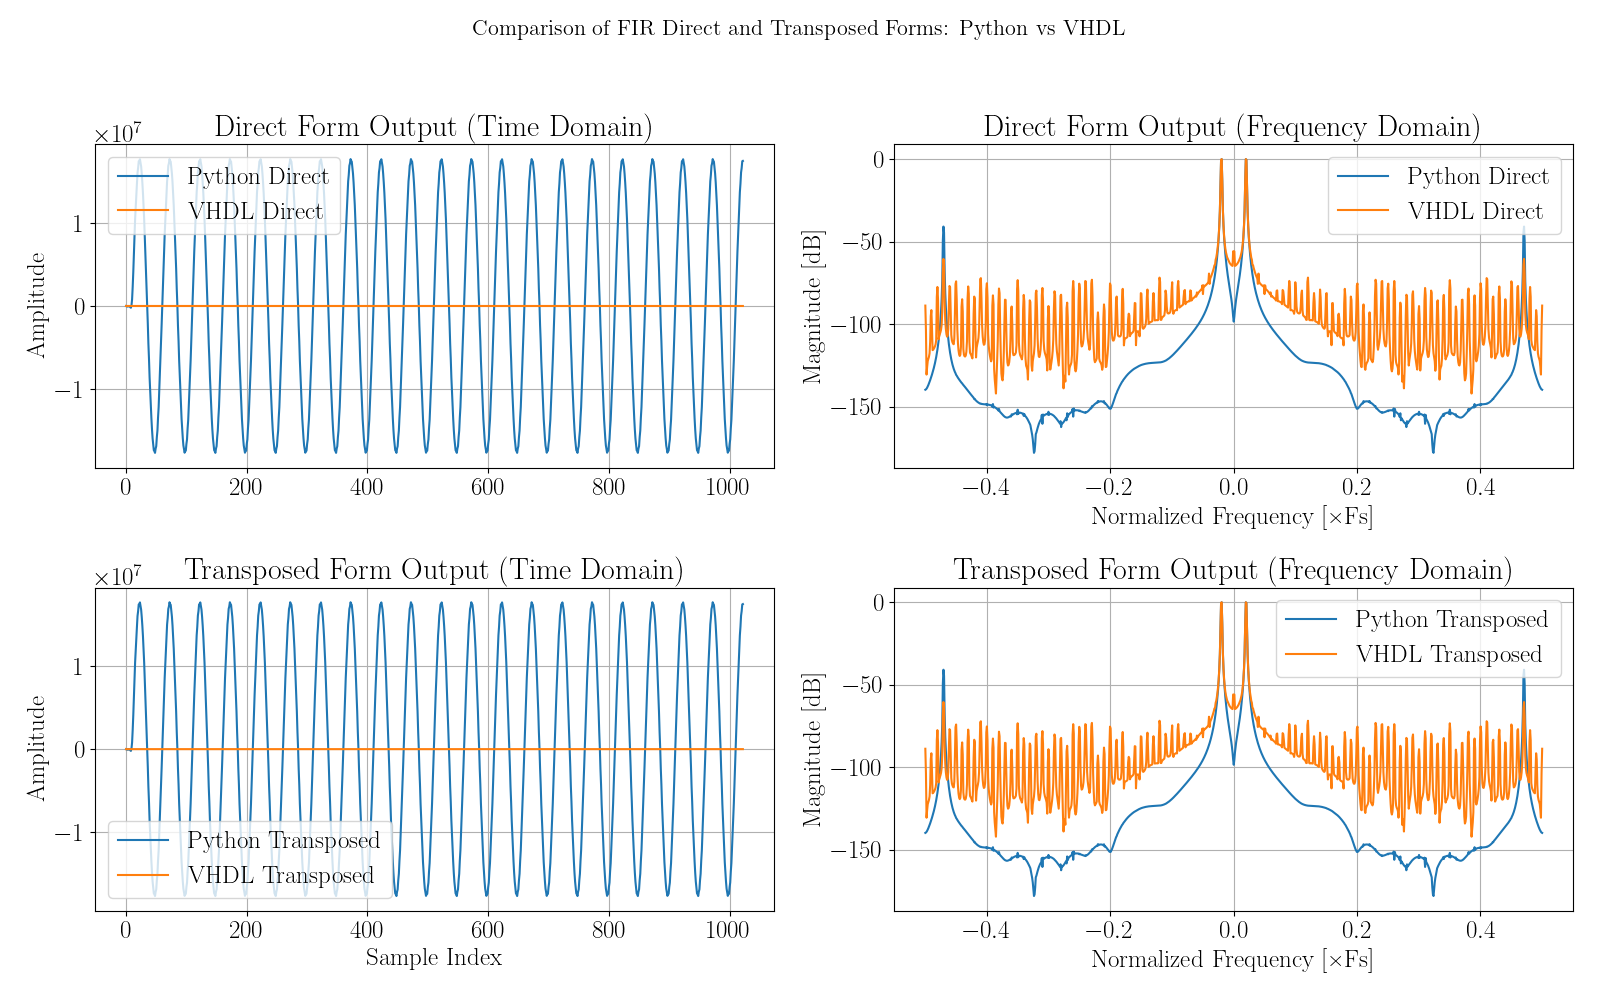

In [102]:
xout_py_dir = fir_direct_q1n(xin_fir_q, fir_coeff_q, n_frac)[:-1]
xout_py_tran = fir_transposed_q1n(xin_fir_q, fir_coeff_q, n_frac)[:-1]
xout_vhdl_dir = np.loadtxt("../vhdl/data/fir/output/xout_direct.txt", dtype=np.int32)[1:]
xout_vhdl_tran = np.loadtxt("../vhdl/data/fir/output/xout_transposed.txt", dtype=np.int32)[1:]

xout_py_dir_fftdB = fftdB(xout_py_dir, win=True)
xout_py_dir_fftdB -= np.max(xout_py_dir_fftdB)
xout_vhdl_dir_fftdB = fftdB(xout_vhdl_dir, win=True)
xout_vhdl_dir_fftdB -= np.max(xout_vhdl_dir_fftdB)

xout_py_tran_fftdB = fftdB(xout_py_tran, win=True)
xout_py_tran_fftdB -= np.max(xout_py_tran_fftdB)
xout_vhdl_tran_fftdB = fftdB(xout_vhdl_tran, win=True)
xout_vhdl_tran_fftdB -= np.max(xout_vhdl_tran_fftdB)

freqs = np.linspace(-0.5, 0.5, len(xout_py_dir_fftdB))

error_direct = np.abs(xout_py_dir-xout_vhdl_dir)
error_transposed = np.abs(xout_py_dir-xout_vhdl_tran)
print(f"Direct error sum: {np.sum(error_direct)}")
print(f"Transposed error sum: {np.sum(error_transposed)}")

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Comparison of FIR Direct and Transposed Forms: Python vs VHDL", fontsize=16, fontweight='bold')

# Direct Form – Time Domain
axs[0, 0].plot(xout_py_dir, label="Python Direct")
axs[0, 0].plot(xout_vhdl_dir, label="VHDL Direct")
axs[0, 0].set_title("Direct Form Output (Time Domain)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].grid(True)
axs[0, 0].legend(loc="best")

# Direct Form – Frequency Domain
axs[0, 1].plot(freqs, xout_py_dir_fftdB, label="Python Direct")
axs[0, 1].plot(freqs, xout_vhdl_dir_fftdB, label="VHDL Direct")
axs[0, 1].set_title("Direct Form Output (Frequency Domain)")
axs[0, 1].set_ylabel("Magnitude [dB]")
axs[0, 1].set_xlabel("Normalized Frequency [×Fs]")
axs[0, 1].grid(True)
axs[0, 1].legend(loc="best")

# Transposed Form – Time Domain
axs[1, 0].plot(xout_py_tran, label="Python Transposed")
axs[1, 0].plot(xout_vhdl_tran, label="VHDL Transposed")
axs[1, 0].set_title("Transposed Form Output (Time Domain)")
axs[1, 0].set_ylabel("Amplitude")
axs[1, 0].set_xlabel("Sample Index")
axs[1, 0].grid(True)
axs[1, 0].legend(loc="best")

# Transposed Form – Frequency Domain
axs[1, 1].plot(freqs, xout_py_tran_fftdB, label="Python Transposed")
axs[1, 1].plot(freqs, xout_vhdl_tran_fftdB, label="VHDL Transposed")
axs[1, 1].set_title("Transposed Form Output (Frequency Domain)")
axs[1, 1].set_ylabel("Magnitude [dB]")
axs[1, 1].set_xlabel("Normalized Frequency [×Fs]")
axs[1, 1].grid(True)
axs[1, 1].legend(loc="best")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.show()

### Tersting Polyphase Decimation Implementation

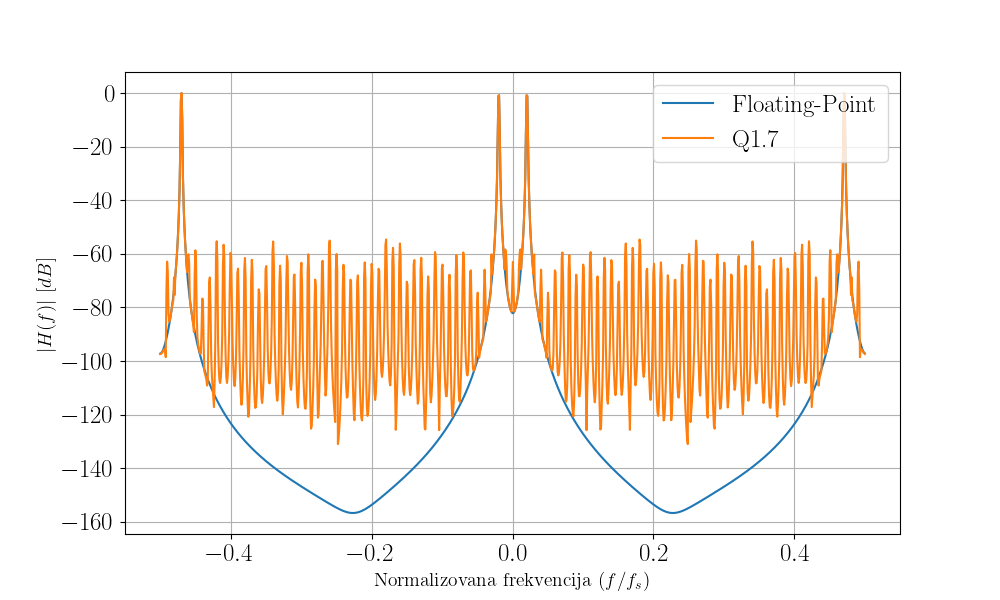

In [103]:
N = 1024
n = np.arange(N)
F1 = 0.02
F2 = 0.47
n_frac = 7
D = 2

xin_dec = 1.0*np.sin(2*np.pi*F1*n) + 1.0*np.sin(2*np.pi*F2*n)
xin_dec_q = float_to_q1n(xin_dec/np.max(xin_dec), n_frac)

fir_coeff_q = np.array(float_to_q1n(fir_coeff, n_frac))

xin_fftdB = fftdB(xin_dec, win=True)
xin_fftdB -= np.max(xin_fftdB)
xin_q_fftdB = fftdB(xin_dec_q, win=True)
xin_q_fftdB -= np.max(xin_q_fftdB)
freqs = np.linspace(-0.5, 0.5, N)

plt.figure(figsize=(10, 6))
plt.plot(freqs, xin_fftdB, label = "Floating-Point")
plt.plot(freqs, xin_q_fftdB, label = f"Q1.{n_frac}")
plt.grid()
plt.legend()
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.show();

In [104]:
np.savetxt("../vhdl/data/polyphase_structures/decimation/poly_decimation.txt", fir_coeff_q, fmt="%d")
np.savetxt("../vhdl/data/polyphase_structures/decimation/input/xin.txt", xin_dec_q, fmt="%d")

# xin_poly = makePolyphase(xin_q, 2)
# np.savetxt("../vhdl/data/fir/input/xin_phase0.txt", xin_poly[0], fmt="%d")
# np.savetxt("../vhdl/data/fir/input/xin_phase1.txt", xin_poly[1], fmt="%d")

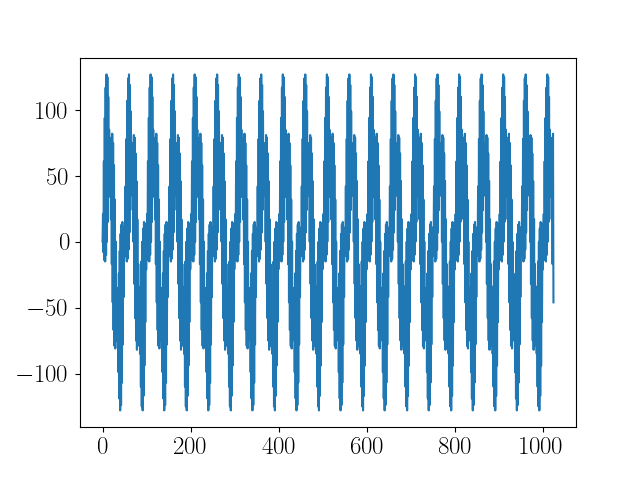

In [105]:
plt.figure()
plt.plot(xin_dec_q)

### Python and VHDL Comparison

In [106]:
xout_py_dec = poly_decimation_q1n(xin_dec_q, fir_coeff_q, D, n_frac)[:-3]
xout_vhdl_dec = np.loadtxt("../vhdl/data/polyphase_structures/decimation/output/xout_decim.txt", dtype=np.int32)[2:]
xout_vhdl_dec = np.loadtxt("./xout_decim.txt", dtype=np.int32)[2:]

# print(len(xout_py_dec), len(xout_vhdl_dec))

xout_py_dec_fftdB = fftdB(xout_py_dec, win=True)
xout_py_dec_fftdB -= np.max(xout_py_dec_fftdB)
xout_vhdl_dec_fftdB = fftdB(xout_vhdl_dec, win=True)
xout_vhdl_dec_fftdB -= np.max(xout_vhdl_dec_fftdB)

error = np.abs(xout_py_dec-xout_vhdl_dec)
print(f"Error sum: {np.sum(error)}")

freqs = np.linspace(-0.5, 0.5, len(xout_py_dec_fftdB))

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Polyphase FIR Decimation: Python vs VHDL", fontsize=16, fontweight='bold')

# Time Domain Plot
axs[0].plot(xout_py_dec, label="Python Output")
axs[0].plot(xout_vhdl_dec, label="VHDL Output")
axs[0].set_title("Decimated Output (Time Domain)")
axs[0].set_xlabel("Sample Index")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend(loc="best")

# Frequency Domain Plot
axs[1].plot(freqs, xout_py_dec_fftdB, label="Python Output")
axs[1].plot(freqs, xout_vhdl_dec_fftdB, label="VHDL Output")
axs[1].set_title("Decimated Output (Frequency Domain)")
axs[1].set_xlabel("Normalized Frequency [×Fs]")
axs[1].set_ylabel("Magnitude [dB]")
axs[1].grid(True)
axs[1].legend(loc="best")

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
plt.show()

FileNotFoundError: ./xout_decim.txt not found.

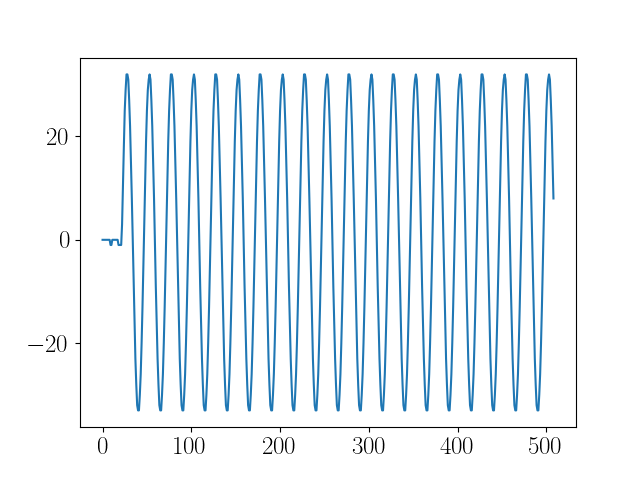

In [86]:
plt.figure()
plt.plot(xout_py_dec)

### Tersting Polyphase Interpolation Implementation

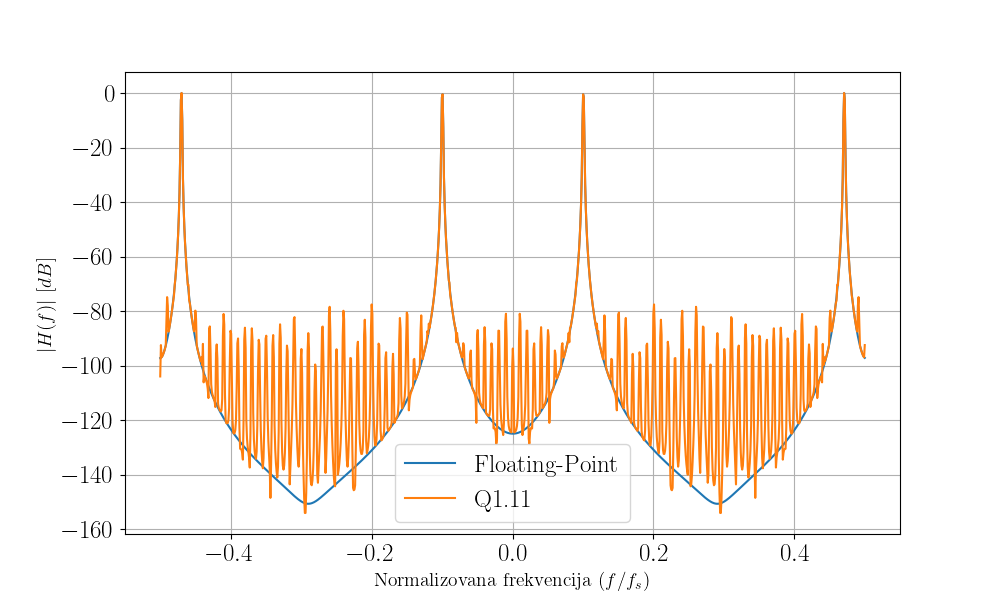

In [15]:
N = 1024
n = np.arange(N)
F1 = 0.1
F2 = 0.47
n_frac = 11
D = 2

xin_int = 1.0*np.sin(2*np.pi*F1*n) + 1.0*np.sin(2*np.pi*F2*n)
xin_int_q = float_to_q1n(xin_int/np.max(xin_int), n_frac)

xin_fftdB = fftdB(xin_int, win=True)
xin_fftdB -= np.max(xin_fftdB)
xin_q_fftdB = fftdB(xin_poly_q, win=True)
xin_q_fftdB -= np.max(xin_q_fftdB)
freqs = np.linspace(-0.5, 0.5, N)

plt.figure(figsize=(10, 6))
plt.plot(freqs, xin_fftdB, label = "Floating-Point")
plt.plot(freqs, xin_q_fftdB, label = f"Q1.{n_frac}")
plt.grid()
plt.legend()
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.show();